In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# Carga de datos
df = pd.read_csv('housing.csv')

<class 'pandas.DataFrame'>


In [ ]:
# Inspección rápida
print("--- Estructura del Dataset ---")
#print(df.info())
print("\n--- Estadísticos Descriptivos ---")
#display = df.describe()
#print(display)

Detección de casos nulos, outliers y nro de casos con outliers

Valres faltantes por columna:
total_bedrooms    207
dtype: int64


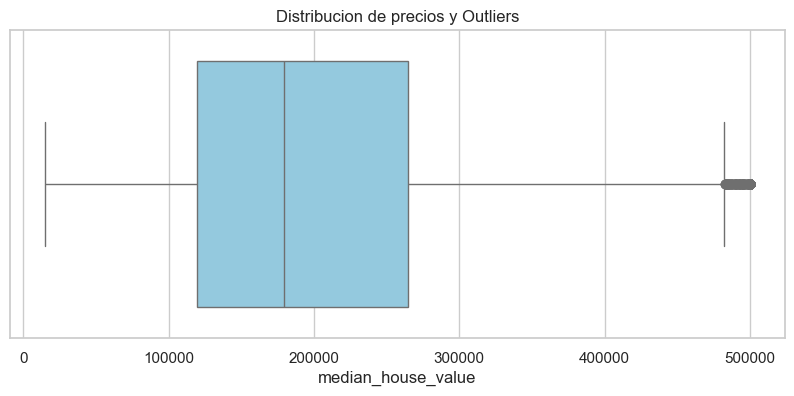

Casos con el precio máximo de 500001.0: 965


In [14]:
#Detectar valores nulos
nulos = df.isnull().sum()
print(f"Valres faltantes por columna:\n{nulos[nulos > 0]}")

# Visualizar outliers en el precio
plt.figure(figsize=(10,4))
sns.boxplot(x=df['median_house_value'], color='skyblue')
plt.title('Distribucion de precios y Outliers')
plt.show()

# 3. Detectar el "Cap" (tope artificial)
precio_max = df['median_house_value'].max()
conteo_max = (df['median_house_value'] == precio_max).sum()
print(f"Casos con el precio máximo de {precio_max}: {conteo_max}")

Limpieza y Transformación de datos

In [28]:
#Tratamiento de nulos con la mediana
mediana_bedrooms = df['total_bedrooms'].median()
df['total_dormitorios'] = df['total_bedrooms'].fillna(mediana_bedrooms)

#Creamos variables con sentido de negocio
#Numero de cuartos por hogar
df ['habitacion_por_casa'] = df['total_rooms'] / df['households']
#Numero de camas por habitacion
df['dormitorios_por_habitacion'] = df['total_dormitorios'] / df['total_rooms']
#Numero de poblacion por hogar
df['popularidad_por_habitacion'] = df['population'] / df['households']

#Limpieza de outliers
#Se elimina todo lo que esta por encima de 500k
df_clean = df[df['median_house_value'] < 500001].copy()

print(f'Registros originales {len(df)}')
print(f'Registros tras eliminar el "cap" de precio: {len(df_clean)}')


Registros originales 20640
Registros tras eliminar el "cap" de precio: 19675
